# 03. Análise Exploratória — Panorama do Catálogo (H1, H3, H6)

## Objetivo deste notebook

Panorama geral do catálogo: tipo de conteúdo, classificação indicativa e duração/formato
ao longo do tempo de adição à plataforma.

## Hipóteses cobertas

| ID | Pergunta de Negócio | Métrica Operacional |
|---|---|---|
| **H1** | Como o mix de Filmes vs. Séries evoluiu? | Volume de adições por ano (`year_added`), segmentado por `type` |
| **H3** | Qual a distribuição por rating e como mudou no tempo? | Distribuição geral de `rating` + % de conteúdo adulto por `year_added` |
| **H6** | Houve variação na duração/formato dos títulos? | Média de duração (Filmes) e mediana de temporadas (Séries), por `year_added` |

## Ajuste metodológico (pós-auditoria de robustez em H4)

A mesma distorção identificada em H4 — anos com volume muito baixo (2008–2015: 1 a 82
títulos/ano) gerando percentuais e médias instáveis — também afeta H1, H3 e H6. Este
notebook aplica o mesmo filtro `MIN_YEARLY_VOLUME >= 100` validado anteriormente,
restringindo as séries temporais a **2016–2020**. A distribuição geral (não temporal) de
`type` e `rating` continua usando a base completa, já que nesses casos não há agregação
por ano.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use('dark_background')

NETFLIX_RED = "#E50914"
SILVER = "#B3B3B3"
BG_COLOR = "#141414"
GRID_COLOR = "#2A2A2A"
TEXT_COLOR = "#FFFFFF"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR, "axes.facecolor": BG_COLOR, "savefig.facecolor": BG_COLOR,
    "axes.edgecolor": GRID_COLOR, "axes.labelcolor": TEXT_COLOR, "axes.titlecolor": TEXT_COLOR,
    "text.color": TEXT_COLOR, "xtick.color": TEXT_COLOR, "ytick.color": TEXT_COLOR,
    "grid.color": GRID_COLOR, "grid.alpha": 0.5, "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.figsize": (12, 6), "legend.frameon": False,
})
df = pd.read_csv(r'C:\Users\lukin\OneDrive\Documentos\netflix_catalog_analysis\data\processed\netflix_titles_clean.csv')
df['date_added_clean'] = pd.to_datetime(df['date_added_clean'])
print(f"Dataset carregado: {len(df)} registros")

Dataset carregado: 8807 registros


In [16]:
MIN_YEARLY_VOLUME = 100

yearly_totals_check = df.dropna(subset=['date_added_clean']).copy()
yearly_totals_check = yearly_totals_check[yearly_totals_check['year_added'] <= 2020]
yearly_totals_check = yearly_totals_check.groupby('year_added').size()

years_valid = yearly_totals_check[yearly_totals_check >= MIN_YEARLY_VOLUME].index
years_excluded = sorted(set(yearly_totals_check.index) - set(years_valid))

print(f"Volume por ano:\n{yearly_totals_check.sort_index()}")
print(f"\nAnos excluídos (<{MIN_YEARLY_VOLUME} títulos): {years_excluded}")
print(f"Anos considerados robustos: {sorted(years_valid)}")

df_temp = df.dropna(subset=['date_added_clean']).copy()
df_temp = df_temp[df_temp['year_added'].isin(years_valid)]
print(f"\nRegistros válidos para as séries temporais: {len(df_temp)}")

Volume por ano:
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
dtype: int64

Anos excluídos (<100 títulos): [2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0]
Anos considerados robustos: [2016.0, 2017.0, 2018.0, 2019.0, 2020.0]

Registros válidos para as séries temporais: 7161


Movie: 6131 (69.62%)
TV Show: 2676 (30.38%)


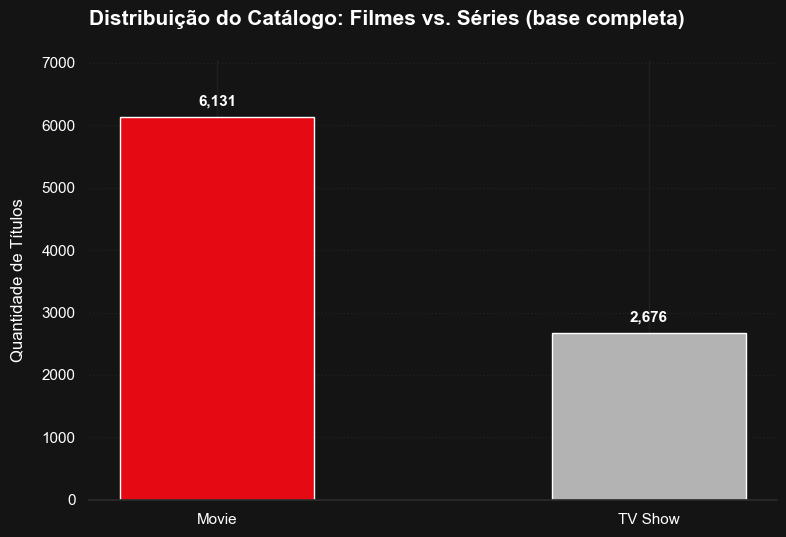

In [21]:
type_counts = df['type'].value_counts()
type_pct = df['type'].value_counts(normalize=True) * 100

for t in type_counts.index:
    print(f"{t}: {type_counts[t]} ({type_pct[t]:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

bars = ax.bar(type_counts.index, type_counts.values, color=[NETFLIX_RED, SILVER], width=0.45)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 8), textcoords="offset points",
                ha='center', fontsize=11, fontweight='bold', color=TEXT_COLOR)

ax.set_title("Distribuição do Catálogo: Filmes vs. Séries (base completa)", pad=25, loc='left', fontsize=15)
ax.set_ylabel("Quantidade de Títulos", labelpad=12)
ax.set_ylim(0, max(type_counts.values) * 1.15)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False, labelleft=True)
ax.yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

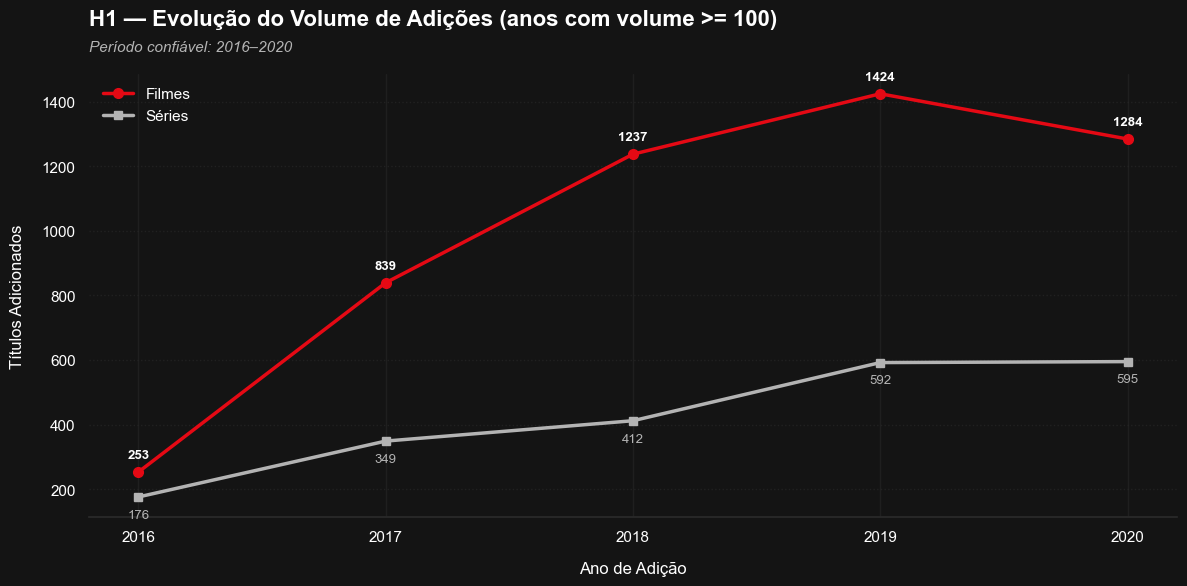

Ano de pico — Filmes: 2019.0
Ano de pico — Séries: 2020.0

Crescimento Ano a Ano (%), apenas anos robustos:
year_added
2016.0      NaN
2017.0    176.9
2018.0     38.8
2019.0     22.3
2020.0     -6.8
dtype: float64


In [22]:
yearly_additions = (
    df_temp.groupby(['year_added', 'type'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

ax.plot(yearly_additions.index, yearly_additions['Movie'],
        marker='o', markersize=7, label='Filmes', linewidth=2.5, color=NETFLIX_RED)
ax.plot(yearly_additions.index, yearly_additions['TV Show'],
        marker='s', markersize=6, label='Séries', linewidth=2.5, color=SILVER)

for year in yearly_additions.index:
    ax.annotate(f"{yearly_additions.loc[year, 'Movie']}", 
                (year, yearly_additions.loc[year, 'Movie']),
                textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold', color=TEXT_COLOR, fontsize=9.5)
    ax.annotate(f"{yearly_additions.loc[year, 'TV Show']}", 
                (year, yearly_additions.loc[year, 'TV Show']),
                textcoords="offset points", xytext=(0, -15), ha='center', color=SILVER, fontsize=9.5)

ax.set_title(f"H1 — Evolução do Volume de Adições (anos com volume >= {MIN_YEARLY_VOLUME})", loc='left', pad=35, fontsize=16)
ax.text(0, 1.05, f"Período confiável: {min(years_valid):.0f}–2020", transform=ax.transAxes,
        color=SILVER, fontsize=11, style='italic')

ax.set_xlabel("Ano de Adição", labelpad=12)
ax.set_ylabel("Títulos Adicionados", labelpad=12)
ax.legend(loc='upper left', facecolor=BG_COLOR, edgecolor=GRID_COLOR)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.spines['left'].set_visible(False)
ax.tick_params(left=False, labelleft=True)
ax.yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("Ano de pico — Filmes:", yearly_additions['Movie'].idxmax())
print("Ano de pico — Séries:", yearly_additions['TV Show'].idxmax())

yoy_growth = yearly_additions.sum(axis=1).pct_change() * 100
print("\nCrescimento Ano a Ano (%), apenas anos robustos:")
print(yoy_growth.round(1))

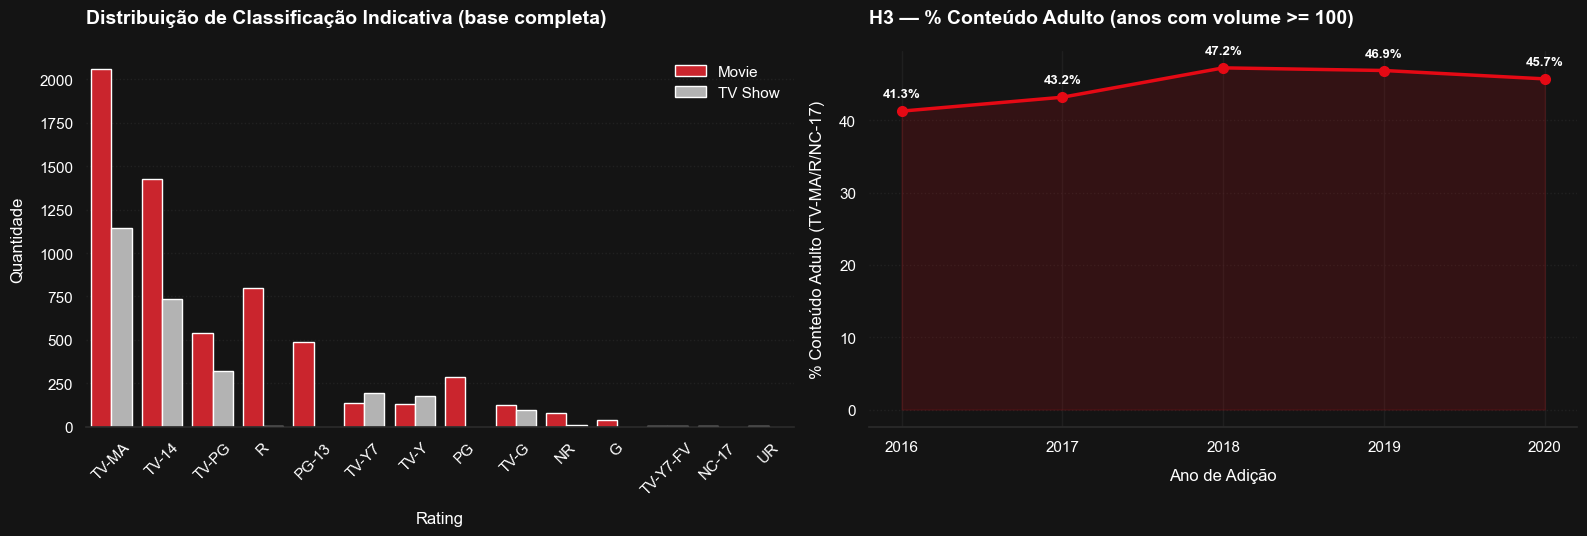

Percentual total de conteúdo adulto no catálogo (base completa): 45.52%
Faixa de variação nos anos robustos: 41.3% a 47.2%


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), facecolor=BG_COLOR)
for ax in axes:
    ax.set_facecolor(BG_COLOR)

rating_order = df['rating'].value_counts().index
sns.countplot(data=df, x='rating', order=rating_order, hue='type',
              palette=[NETFLIX_RED, SILVER], ax=axes[0])
axes[0].set_title("Distribuição de Classificação Indicativa (base completa)", pad=20, loc='left', fontsize=14)
axes[0].set_xlabel("Rating", labelpad=10)
axes[0].set_ylabel("Quantidade", labelpad=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(facecolor=BG_COLOR, edgecolor=GRID_COLOR)
axes[0].spines['left'].set_visible(False)
axes[0].tick_params(left=False, labelleft=True)
axes[0].yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

adult_ratings = ['TV-MA', 'R', 'NC-17']
df_temp['is_adult'] = df_temp['rating'].isin(adult_ratings)
adult_by_year = df_temp.groupby('year_added')['is_adult'].mean() * 100

axes[1].plot(adult_by_year.index, adult_by_year.values,
             marker='o', markersize=7, color=NETFLIX_RED, linewidth=2.5)
axes[1].fill_between(adult_by_year.index, adult_by_year.values, color=NETFLIX_RED, alpha=0.15)

for year, val in zip(adult_by_year.index, adult_by_year.values):
    axes[1].annotate(f"{val:.1f}%", (year, val), textcoords="offset points", xytext=(0, 10),
                     ha='center', fontweight='bold', color=TEXT_COLOR, fontsize=9.5)

axes[1].set_title(f"H3 — % Conteúdo Adulto (anos com volume >= {MIN_YEARLY_VOLUME})", pad=20, loc='left', fontsize=14)
axes[1].set_xlabel("Ano de Adição", labelpad=10)
axes[1].set_ylabel("% Conteúdo Adulto (TV-MA/R/NC-17)", labelpad=10)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))
axes[1].spines['left'].set_visible(False)
axes[1].tick_params(left=False, labelleft=True)
axes[1].yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

pct_adult_total = (df['rating'].isin(adult_ratings).sum() / len(df)) * 100
print(f"Percentual total de conteúdo adulto no catálogo (base completa): {pct_adult_total:.2f}%")
print(f"Faixa de variação nos anos robustos: {adult_by_year.min():.1f}% a {adult_by_year.max():.1f}%")

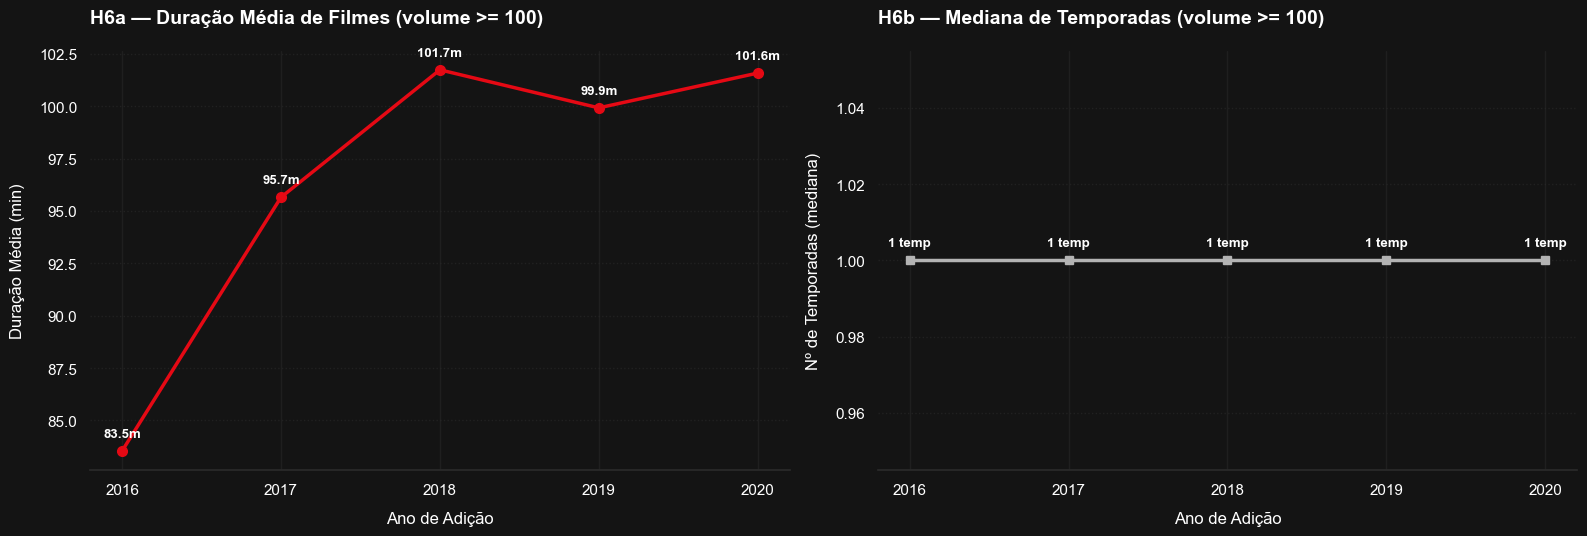

Duração média filmes — 2016: 83.5min | 2020: 101.6min
Mediana temporadas — 2016: 1.0 | 2020: 1.0


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), facecolor=BG_COLOR)
for ax in axes:
    ax.set_facecolor(BG_COLOR)

df_movies_temp = df_temp[df_temp['type'] == 'Movie']
movie_dur_by_year = df_movies_temp.groupby('year_added')['duration_num'].mean()

axes[0].plot(movie_dur_by_year.index, movie_dur_by_year.values,
             marker='o', markersize=7, color=NETFLIX_RED, linewidth=2.5)
for year, val in zip(movie_dur_by_year.index, movie_dur_by_year.values):
    axes[0].annotate(f"{val:.1f}m", (year, val), textcoords="offset points", xytext=(0, 10),
                     ha='center', fontweight='bold', color=TEXT_COLOR, fontsize=9.5)

axes[0].set_title(f"H6a — Duração Média de Filmes (volume >= {MIN_YEARLY_VOLUME})", pad=20, loc='left', fontsize=14)
axes[0].set_xlabel("Ano de Adição", labelpad=10)
axes[0].set_ylabel("Duração Média (min)", labelpad=10)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))
axes[0].spines['left'].set_visible(False)
axes[0].tick_params(left=False, labelleft=True)
axes[0].yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

df_tv_temp = df_temp[df_temp['type'] == 'TV Show']
tv_seasons_by_year = df_tv_temp.groupby('year_added')['duration_num'].median()

axes[1].plot(tv_seasons_by_year.index, tv_seasons_by_year.values,
             marker='s', markersize=6, color=SILVER, linewidth=2.5)
for year, val in zip(tv_seasons_by_year.index, tv_seasons_by_year.values):
    axes[1].annotate(f"{val:.0f} temp", (year, val), textcoords="offset points", xytext=(0, 10),
                     ha='center', fontweight='bold', color=TEXT_COLOR, fontsize=9.5)

axes[1].set_title(f"H6b — Mediana de Temporadas (volume >= {MIN_YEARLY_VOLUME})", pad=20, loc='left', fontsize=14)
axes[1].set_xlabel("Ano de Adição", labelpad=10)
axes[1].set_ylabel("Nº de Temporadas (mediana)", labelpad=10)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))
axes[1].spines['left'].set_visible(False)
axes[1].tick_params(left=False, labelleft=True)
axes[1].yaxis.grid(True, color=GRID_COLOR, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Duração média filmes — {movie_dur_by_year.index.min():.0f}: {movie_dur_by_year.iloc[0]:.1f}min | 2020: {movie_dur_by_year.iloc[-1]:.1f}min")
print(f"Mediana temporadas — {tv_seasons_by_year.index.min():.0f}: {tv_seasons_by_year.iloc[0]:.1f} | 2020: {tv_seasons_by_year.iloc[-1]:.1f}")